\
Circadian soundscape
===================================================

When dealing with large amounts of audio recordings, visualization plays a key role to evidence the main patterns in the data. In this example we show how to easily combine audio files to build a visual representation of a 24 hour natural soundscape..


## Set variables



In [1]:
sample_len = 30  # length in seconds of each audio slice

SAMPLE_RATE = 384000 # 36000 or 384000

hlim_start ='17:00' # rec7 '17:15' # rec6 '17:30' rec6_ultra '17:30'  rec4 '16:30' rec4_v2 '06:30' rec3 '06:15' rec1 '17:15' # for the spectrogram : First point on the x axis
hlim_end = '08:00' # rec7 '11:15' # rec6 '09:30 rec6_ultra '09:30   # rec4 '06:30' rec4_v2 '08:30' rec3 '09:45' rec1 '09:15'    # for the spectrogram : Last point on the x axis

## audible
# flim_min = 0  #in Hz
# flim_max = SAMPLE_RATE//2 #in Hz


## ultrasound
flim_min = 20000  #in Hz
flim_max = 80000 #in Hz



## Step 1 - Setup the environment
---

Get the information about the virtual machine that Google gave you

In [2]:
# get info about the virtual machine
!lscpu |grep 'Model name'
!lscpu |grep 'Core(s) per socket:'
!free -h --si | awk  '/Mem:/{print $2}'

Model name:                         13th Gen Intel(R) Core(TM) i7-13700H
Core(s) per socket:                 14
63G


### 1.1 Global settings

Change or adapt the settings :
- to import the required packages
- to set the directories and the paths
- to set some global constatns
- to set the parameters for bambird

In [3]:
# Load basic packages
# --------------------
import shutil
import numpy as np
from pathlib import Path
import os
import datetime
import sys
import pandas as pd
import glob
import matplotlib.pyplot as plt
import librosa

from maad import sound, util, spl


In [4]:
# Define constants
# ----------------

# add shortcut to the link (https://drive.google.com/drive/folders/13OVJdujQoG5zjLwLVwC16mxUDNmGFNXb?usp=share_link)
# into your own googledrdive in order to have access to the remote folder
# !!! NEED TO BE ADAPTED TO YOU OWN CONFIG !!!
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Mock-Dataset/active/canopy_dome_10b_32khz')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Mock-Dataset/active/canopy_dome_01a_32khz')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec1dmu')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec3dmu')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec4dmu')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec4dmu_v2')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec6dmu')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec7dmu')

# ULTRASONS
ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_ultrasound/rec1dmu_ultra')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_ultrasound/rec4dmu_ultra')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_ultrasound/rec6dmu_ultra')

SAVE_PATH       = Path('/media/haupert/data/mes_projets/05_xprize/final')

# subsample the dataframe containing all the audio recordings
EVERY_N_ROWS = 1 # Set to 1 to keep all files.

## Step 2 - Process audio and display the long term spectrogram
---


Get the mean, mead or max of each row of the spectrogram to build the long term spectro

In [9]:
flist = glob.glob(str(ARCHIVE_PATH)+'/*.wav')
flist.sort()
Sxx = []
for idx, fname in enumerate(flist):
    s, fs = sound.load(fname)
    Sxx_temp, tn, fn, ext = sound.spectrogram(s, fs,
                                        window='hann',
                                        nperseg=4096//4,
                                        noverlap=4096//4//2,
                                        flims=[flim_min, flim_max])
    #Sxx.append(Sxx_temp.max(axis=1))
    # Sxx.append(Sxx_temp.min(axis=1))
    # Sxx.append(np.percentile(Sxx_temp, 50, axis=1))
    # Sxx.append(np.percentile(Sxx_temp, 75, axis=1))
    Sxx.append(np.percentile(Sxx_temp, 99, axis=1))

# Convert the list to a NumPy array
Sxx = np.array(Sxx)

print('Check the date and hours : ')
print('- first file : {}'.format(Path(flist[0]).stem))
print('- last file : {}'.format(Path(flist[-1]).stem))

Check the date and hours : 
- first file : 20240720_172000
- last file : 20240721_090400


Display the spectrogram.

In [10]:
# Create a vector of hours from hlim_start to 11:59 PM
range1 = pd.date_range(start=hlim_start, end='23:59', freq='H').strftime('%H:%M')

# Create a vector of hours from 00:00 AM to hlim_end
range2 = pd.date_range(start='00:00', end=hlim_end, freq='H').strftime('%H:%M')

# Concatenate the two ranges
hours = list(range1) + list(range2)

# """ 
#         in case of the same day (rec3dmu)
# """
# # Create a vector of hours from hlim_start to 11:59 PM
# range1 = pd.date_range(start=hlim_start, end=hlim_end, freq='H').strftime('%H:%M')

# # Concatenate the two ranges
# hours = list(range1)


In [11]:
hours

['17:00',
 '18:00',
 '19:00',
 '20:00',
 '21:00',
 '22:00',
 '23:00',
 '00:00',
 '01:00',
 '02:00',
 '03:00',
 '04:00',
 '05:00',
 '06:00',
 '07:00',
 '08:00']

Text(90.34722222222221, 0.5, 'Frequency [kHz]')

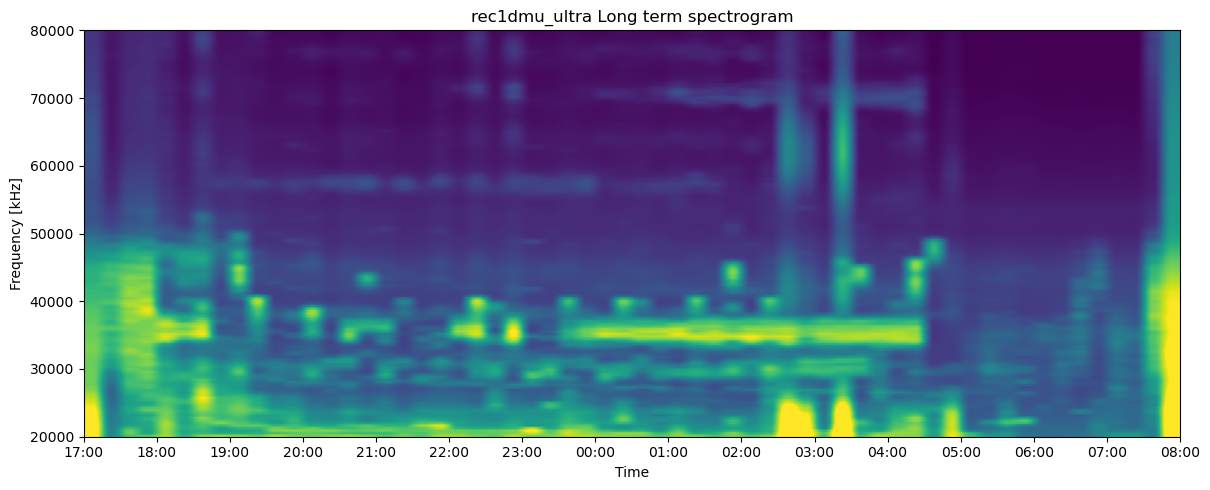

In [13]:
# full length
fig, ax = plt.subplots(1,1, figsize=(12,5)) # rec1 (12,5) rec3 (3.75,5) rec4(10.5,5) rec4_v2 (2.75, 5) rec6 (12.5, 5) rec7 (14, 5) rec4_ultra (11.5, 5)  rec6_ultra(12.5, 5) rec1_ultra(12.5, 5)
# rec3dmu
# fig, ax = plt.subplots(1,1, figsize=(4,8))

Sxx_dB = util.power2dB(Sxx,db_range=96) + 96
util.plot2d(Sxx_dB.T,
            ax=ax,
            title=str(ARCHIVE_PATH.stem) + ' Long term spectrogram',
            extent=[0, len(hours)-1, flim_min, flim_max],
            vmin=np.percentile(Sxx_dB,1),
            vmax=np.percentile(Sxx_dB,99),
            colorbar=False,
            cmap='viridis')


ax.set_xlabel('Time')
ax.set_xticks(range(len(hours)), hours, rotation=0)
ax.set_ylabel('Frequency [kHz]')

